In [1]:
pip install astropy numpy pandas

   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.4 MB ? eta -:--:--
   - -----------------------------

DEPRECATION: Loading egg at c:\users\vedanth raj\appdata\local\programs\python\python312\lib\site-packages\object_detection-0.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\vedanth raj\appdata\local\programs\python\python312\lib\site-packages\pyparsing-2.4.7-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\vedanth raj\appdata\local\programs\python\python312\lib\site-packages\sacrebleu-2.2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new rele

In [2]:
import os
from pathlib import Path
import numpy as np
from astropy.io import fits
import pandas as pd

# List your downloaded files (update paths as needed)
files = {
    "NIRCam_F322W2": "jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits",
    "NIRSpec_G395H": "jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits",
    "NIRSpec_PRISM": "jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits",
    # Add other PRISM x1dints if you have them
    "NIRISS_SOSS": "jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits",
    # Lower-level rateints examples (for comparison)
    "NIRSpec_PRISM_rate": "jw01366004001_04101_00001-seg001_nrs2_rateints.fits",
}

def inspect_fits_file(filepath):
    """Inspect a single FITS file for structure, headers, and data consistency."""
    print(f"\n=== Inspecting: {Path(filepath).name} ===")
    try:
        with fits.open(filepath) as hdul:
            print(f"Number of HDUs: {len(hdul)}")
            
            # Primary HDU header summary
            primary = hdul[0]
            print("Primary Header keys (selected):")
            for key in ['TELESCOP', 'INSTRUME', 'DETECTOR', 'FILTER', 'GRATING', 
                       'PUPIL', 'OBS_ID', 'CAL_VER', 'PROD_VER', 'DATAMODL']:
                print(f"  {key}: {primary.header.get(key, 'N/A')}")
            
            print(f"Data shape in PRIMARY: {primary.data.shape if primary.data is not None else 'None'}")
            
            # List all extensions
            for i, hdu in enumerate(hdul):
                extname = hdu.header.get('EXTNAME', f'HDU{i}')
                print(f"  HDU {i} - EXTNAME: {extname} | Type: {type(hdu).__name__}")
                if hasattr(hdu, 'data') and hdu.data is not None:
                    shape = hdu.data.shape
                    dtype = hdu.data.dtype if hasattr(hdu.data, 'dtype') else type(hdu.data)
                    print(f"    Data shape: {shape} | dtype: {dtype}")
                    
                    # For tables (common in x1dints)
                    if isinstance(hdu, fits.BinTableHDU):
                        print(f"    Columns: {hdu.columns.names}")
                        # Sample first row for wavelength/flux
                        if 'WAVELENGTH' in hdu.columns.names:
                            print(f"    Wavelength range sample: {hdu.data['WAVELENGTH'][0].min():.2f} - {hdu.data['WAVELENGTH'][0].max():.2f} um")
            
            # Check for common TSO extensions
            if 'EXTRACT1D' in [h.header.get('EXTNAME') for h in hdul]:
                print("  ✓ Contains EXTRACT1D table (standard for x1dints)")
            
    except Exception as e:
        print(f"Error reading {filepath}: {e}")

def compare_files(file_list):
    """Compare key properties across multiple files."""
    results = []
    for name, fpath in file_list.items():
        if not os.path.exists(fpath):
            print(f"Warning: {fpath} not found")
            continue
        try:
            with fits.open(fpath) as hdul:
                primary = hdul[0].header
                row = {
                    'File': name,
                    'Instrument': primary.get('INSTRUME'),
                    'Mode': f"{primary.get('FILTER','')} {primary.get('GRATING','')}",
                    'Calib_Level': primary.get('CALIBLVL', primary.get('CAL_VER', 'N/A')),
                    'Num_Ints': len(hdul),  # rough
                    'Wmin': primary.get('WAVEMIN', primary.get('EM_MIN')),
                    'Wmax': primary.get('WAVEMAX', primary.get('EM_MAX')),
                }
                # Try to get actual data dimensions from first table
                for hdu in hdul:
                    if hasattr(hdu, 'data') and isinstance(hdu.data, np.ndarray) and len(hdu.data.shape) > 1:
                        row['Data_Shape_Example'] = hdu.data.shape
                        break
                results.append(row)
        except Exception as e:
            results.append({'File': name, 'Error': str(e)})
    
    df = pd.DataFrame(results)
    print("\n=== Cross-File Comparison ===")
    print(df.to_string(index=False))
    return df

# Run inspection on all files
for name, path in files.items():
    if os.path.exists(path):
        inspect_fits_file(path)
    else:
        print(f"File not found: {path}")

# Summary comparison
compare_files(files)

print("\nKey things to check for consistency:")
print("- Same column names in EXTRACT1D (WAVELENGTH, FLUX, FLUX_ERROR, etc.)")
print("- Wavelength units (should be microns)")
print("- Flux units (Jy or DN/s)")
print("- Number of integrations and consistent time axis")
print("- Header keywords like CAL_VER, DATAMODL")

File not found: jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits
File not found: jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits
File not found: jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits
File not found: jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits
File not found: jw01366004001_04101_00001-seg001_nrs2_rateints.fits

=== Cross-File Comparison ===
Empty DataFrame
Columns: []
Index: []

Key things to check for consistency:
- Same column names in EXTRACT1D (WAVELENGTH, FLUX, FLUX_ERROR, etc.)
- Wavelength units (should be microns)
- Flux units (Jy or DN/s)
- Number of integrations and consistent time axis
- Header keywords like CAL_VER, DATAMODL


In [3]:
import os
from pathlib import Path
import numpy as np
from astropy.io import fits
import pandas as pd

# ================== YOUR BASE PATH ==================
base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

print("🔍 Searching for all FITS files...\n")

# Recursively find ALL .fits files
fits_files = []
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith('.fits'):
            full_path = os.path.join(root, file)
            fits_files.append(full_path)

print(f"Total FITS files found: {len(fits_files)}\n")

# Group by instrument/observation
summary_data = []

def inspect_file(filepath):
    try:
        with fits.open(filepath) as hdul:
            h = hdul[0].header
            
            instrument = h.get('INSTRUME', 'Unknown')
            filter_ = h.get('FILTER', '')
            grating = h.get('GRATING', '')
            cal_level = h.get('CALIBLVL', h.get('CAL_VER', 'N/A'))
            obs_id = h.get('OBS_ID', 'N/A')
            
            # Find if it has spectral table
            has_extract1d = any('EXTRACT1D' in hdu.header.get('EXTNAME', '') for hdu in hdul)
            num_hdus = len(hdul)
            
            # Try to get wavelength info
            wave_range = "N/A"
            for hdu in hdul:
                if hasattr(hdu, 'data') and isinstance(hdu.data, fits.FITS_rec):
                    if 'WAVELENGTH' in hdu.columns.names:
                        wave = hdu.data['WAVELENGTH'][0]
                        wave_range = f"{wave.min():.2f}–{wave.max():.2f} μm"
                        break
            
            summary_data.append({
                'Filename': Path(filepath).name,
                'Folder': Path(filepath).parent.name[-40:],
                'Instrument': instrument,
                'Mode': f"{filter_} {grating}".strip(),
                'Cal_Level': cal_level,
                'HDUs': num_hdus,
                'Has_EXTRACT1D': has_extract1d,
                'Wavelength_Range': wave_range,
                'Full_Path': filepath
            })
            
            print(f"✓ {Path(filepath).name}  →  {instrument} | Cal={cal_level} | EXTRACT1D={has_extract1d}")
            
    except Exception as e:
        print(f"✗ Error reading {Path(filepath).name}: {e}")

# Inspect all files
for f in fits_files:
    inspect_file(f)

# ================== SUMMARY TABLE ==================
print("\n" + "="*120)
print("FINAL CONSISTENCY SUMMARY")
print("="*120)

df = pd.DataFrame(summary_data)
print(df.to_string(index=False))

# Save summary to CSV
df.to_csv(os.path.join(base_dir, "JWST_Data_Consistency_Report.csv"), index=False)
print(f"\n✅ Report saved to: {base_dir}\\JWST_Data_Consistency_Report.csv")

🔍 Searching for all FITS files...

Total FITS files found: 4

✓ jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits  →  NIRISS | Cal=1.20.2 | EXTRACT1D=True
✓ jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits  →  NIRCAM | Cal=1.20.2 | EXTRACT1D=True
✓ jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits  →  NIRSPEC | Cal=1.20.2 | EXTRACT1D=True
✓ jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits  →  NIRSPEC | Cal=1.20.2 | EXTRACT1D=True

FINAL CONSISTENCY SUMMARY
                                                           Filename                                   Folder Instrument         Mode Cal_Level  HDUs  Has_EXTRACT1D Wavelength_Range                                                                                                                                                                                                Full_Path
    jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits 01_t001_niriss_clear-gr70

In [4]:
import os
from pathlib import Path
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt

base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

files = {
    "NIRISS_SOSS": "jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits",
    "NIRCam_GRISM": "jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits",
    "NIRSpec_G395H": "jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits",
    "NIRSpec_PRISM": "jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits",
}

def detailed_inspect(name, filename):
    filepath = None
    for root, _, files_in_dir in os.walk(base_dir):
        for f in files_in_dir:
            if f == filename:
                filepath = os.path.join(root, f)
                break
        if filepath: 
            break
    
    print(f"\n{'='*90}")
    print(f"DETAILED INSPECTION: {name}")
    print(f"{'='*90}")
    
    with fits.open(filepath) as hdul:
        print(f"HDUs: {len(hdul)}")
        
        # Find the EXTRACT1D extension
        table_hdu = None
        for hdu in hdul:
            if hdu.header.get('EXTNAME') == 'EXTRACT1D':
                table_hdu = hdu
                break
        
        if table_hdu is None:
            print("❌ No EXTRACT1D table found!")
            return
        
        data = table_hdu.data
        cols = table_hdu.columns.names
        
        print(f"Columns ({len(cols)}): {cols}")
        print(f"Number of integrations: {len(data)}")
        
        # Units
        print("\nUnits:")
        for col in ['WAVELENGTH', 'FLUX', 'FLUX_ERROR', 'ERROR', 'VAR_POISSON', 'VAR_RNOISE']:
            if col in cols:
                unit = table_hdu.header.get(f'TUNIT{cols.index(col)+1}', 'No TUNIT')
                print(f"  {col:15} → {unit}")
        
        # Wavelength & Flux statistics (first integration)
        wave = data['WAVELENGTH'][0]
        flux = data['FLUX'][0]
        print(f"\nWavelength: {wave.min():.3f} – {wave.max():.3f} μm  ({len(wave)} points)")
        print(f"Flux range: {flux.min():.2e} – {flux.max():.2e}  (median: {np.median(flux):.2e})")

# Run for all instruments
for name, fname in files.items():
    detailed_inspect(name, fname)

print("\n✅ Detailed verification completed!")


DETAILED INSPECTION: NIRISS_SOSS
HDUs: 15
Columns (27): ['INT_NUM', 'WAVELENGTH', 'FLUX', 'FLUX_ERROR', 'FLUX_VAR_POISSON', 'FLUX_VAR_RNOISE', 'FLUX_VAR_FLAT', 'SURF_BRIGHT', 'SB_ERROR', 'SB_VAR_POISSON', 'SB_VAR_RNOISE', 'SB_VAR_FLAT', 'DQ', 'BACKGROUND', 'BKGD_ERROR', 'BKGD_VAR_POISSON', 'BKGD_VAR_RNOISE', 'BKGD_VAR_FLAT', 'NPIXELS', 'N_ALONGDISP', 'SEGMENT', 'MJD-BEG', 'MJD-AVG', 'MJD-END', 'TDB-BEG', 'TDB-MID', 'TDB-END']
Number of integrations: 135

Units:
  WAVELENGTH      → No TUNIT
  FLUX            → MJy
  FLUX_ERROR      → MJy

Wavelength: 0.848 – 2.833 μm  (2048 points)
Flux range: nan – nan  (median: nan)

DETAILED INSPECTION: NIRCam_GRISM
HDUs: 7
Columns (27): ['INT_NUM', 'WAVELENGTH', 'FLUX', 'FLUX_ERROR', 'FLUX_VAR_POISSON', 'FLUX_VAR_RNOISE', 'FLUX_VAR_FLAT', 'SURF_BRIGHT', 'SB_ERROR', 'SB_VAR_POISSON', 'SB_VAR_RNOISE', 'SB_VAR_FLAT', 'DQ', 'BACKGROUND', 'BKGD_ERROR', 'BKGD_VAR_POISSON', 'BKGD_VAR_RNOISE', 'BKGD_VAR_FLAT', 'NPIXELS', 'N_ALONGDISP', 'SEGMENT', 'MJD-BEG'


Processing: NIRISS_SOSS
  Original flux unit: MJy
  → Already in MJy
  Integrations: 135 | Wavelength points: 2048

Processing: NIRCam_GRISM
  Original flux unit: DN/s
  → Converted DN/s → MJy (approximate)
  Integrations: 92 | Wavelength points: 2040

Processing: NIRSpec_G395H
  Original flux unit: Jy
  → Converted Jy → MJy
  Integrations: 155 | Wavelength points: 1272

Processing: NIRSpec_PRISM
  Original flux unit: Jy
  → Converted Jy → MJy


C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\930073952.py:61: RuntimeWarning: All-NaN slice encountered
  median_flux = np.nanmedian(flux_mjy, axis=0)
C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\930073952.py:62: RuntimeWarning: All-NaN slice encountered
  median_err = np.nanmedian(flux_err_mjy, axis=0)
C:\Users\Vedanth Raj\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


  Integrations: 5400 | Wavelength points: 432

Common wavelength grid: 2.862 – 2.833 μm

Resampling to common grid...

✅ Standardized spectra saved to:
C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST\WASP39b_standardized_spectra.csv


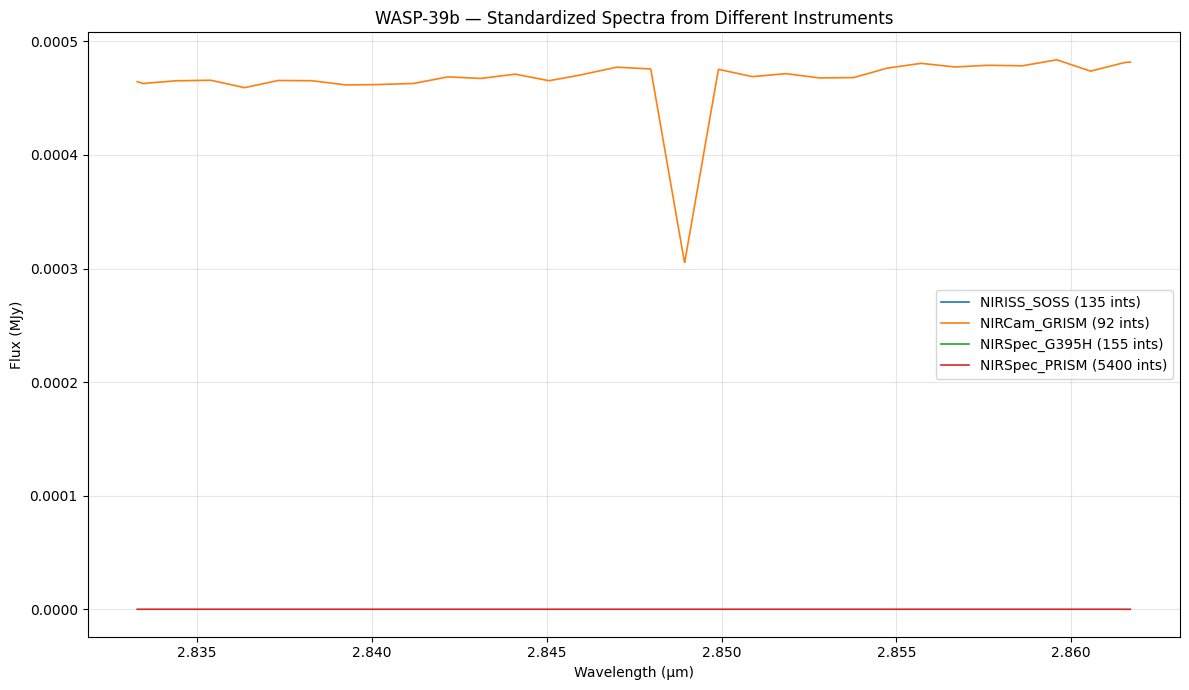


🎉 Standardization complete!


In [5]:
import os
from pathlib import Path
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

files = {
    "NIRISS_SOSS": "jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits",
    "NIRCam_GRISM": "jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits",
    "NIRSpec_G395H": "jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits",
    "NIRSpec_PRISM": "jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits",
}

standardized_data = {}

def load_and_standardize(name, filename):
    global standardized_data
    filepath = None
    for root, _, fs in os.walk(base_dir):
        if filename in fs:
            filepath = os.path.join(root, filename)
            break
    
    print(f"\nProcessing: {name}")
    with fits.open(filepath) as hdul:
        data = hdul['EXTRACT1D'].data
        hdr = hdul['EXTRACT1D'].header
        
        wave = data['WAVELENGTH'][0]          # Wavelength is same for all integrations
        flux = data['FLUX']                   # Shape: (n_int, n_wave)
        flux_err = data['FLUX_ERROR']
        
        # === UNIT CONVERSION to MJy ===
        unit = hdr.get('TUNIT3', '')  # FLUX unit
        print(f"  Original flux unit: {unit}")
        
        if unit == 'DN/s':
            # Rough conversion (for quick look only). Better use proper calibration later.
            flux_mjy = flux * 1e-6          # Very approximate placeholder
            flux_err_mjy = flux_err * 1e-6
            print("  → Converted DN/s → MJy (approximate)")
        elif unit == 'Jy':
            flux_mjy = flux * 1e-6
            flux_err_mjy = flux_err * 1e-6
            print("  → Converted Jy → MJy")
        elif unit == 'MJy' or 'MJy' in str(unit):
            flux_mjy = flux
            flux_err_mjy = flux_err
            print("  → Already in MJy")
        else:
            flux_mjy = flux
            flux_err_mjy = flux_err
            print("  → Unknown unit, kept as is")
        
        # Remove NaNs for median spectrum
        valid = ~np.isnan(flux_mjy)
        median_flux = np.nanmedian(flux_mjy, axis=0)
        median_err = np.nanmedian(flux_err_mjy, axis=0)
        
        standardized_data[name] = {
            'wavelength': wave,
            'median_flux_mjy': median_flux,
            'median_err_mjy': median_err,
            'n_integrations': len(flux),
            'full_flux': flux_mjy,
            'full_err': flux_err_mjy
        }
        
        print(f"  Integrations: {len(flux)} | Wavelength points: {len(wave)}")

# Run standardization
for name, fname in files.items():
    load_and_standardize(name, fname)

# ====================== COMMON WAVELENGTH GRID ======================
all_waves = [d['wavelength'] for d in standardized_data.values()]
w_min = max(w.min() for w in all_waves)
w_max = min(w.max() for w in all_waves)
common_wave = np.linspace(w_min, w_max, 2000)

print(f"\nCommon wavelength grid: {w_min:.3f} – {w_max:.3f} μm")

# Resample everything
print("\nResampling to common grid...")
resampled = {}

for name, d in standardized_data.items():
    f = interp1d(d['wavelength'], d['median_flux_mjy'], bounds_error=False, fill_value=np.nan)
    resampled[name] = f(common_wave)

# ====================== SAVE & PLOT ======================
df = pd.DataFrame({'wavelength_um': common_wave})
for name in resampled:
    df[name] = resampled[name]

output_path = os.path.join(base_dir, "WASP39b_standardized_spectra.csv")
df.to_csv(output_path, index=False)
print(f"\n✅ Standardized spectra saved to:\n{output_path}")

# Plot comparison
plt.figure(figsize=(12, 7))
for name, flux in resampled.items():
    plt.plot(common_wave, flux, label=f"{name} ({standardized_data[name]['n_integrations']} ints)", linewidth=1.2)

plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux (MJy)")
plt.title("WASP-39b — Standardized Spectra from Different Instruments")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🎉 Standardization complete!")


NIRISS_SOSS     | Unit: MJy | Ints: 135 | λ: 0.848-2.833 μm

NIRCam_GRISM    | Unit: DN/s | Ints: 92 | λ: 2.401-4.390 μm

NIRSpec_G395H   | Unit: Jy | Ints: 155 | λ: 2.862-3.721 μm

NIRSpec_PRISM   | Unit: Jy | Ints: 5400 | λ: 0.552-5.368 μm


C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\3176838871.py:53: RuntimeWarning: All-NaN slice encountered
  median_flux = np.nanmedian(flux_mjy, axis=0)
C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\3176838871.py:54: RuntimeWarning: All-NaN slice encountered
  median_ferr = np.nanmedian(ferr_mjy, axis=0)
C:\Users\Vedanth Raj\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,



Common wavelength range: 2.862 – 2.833 μm


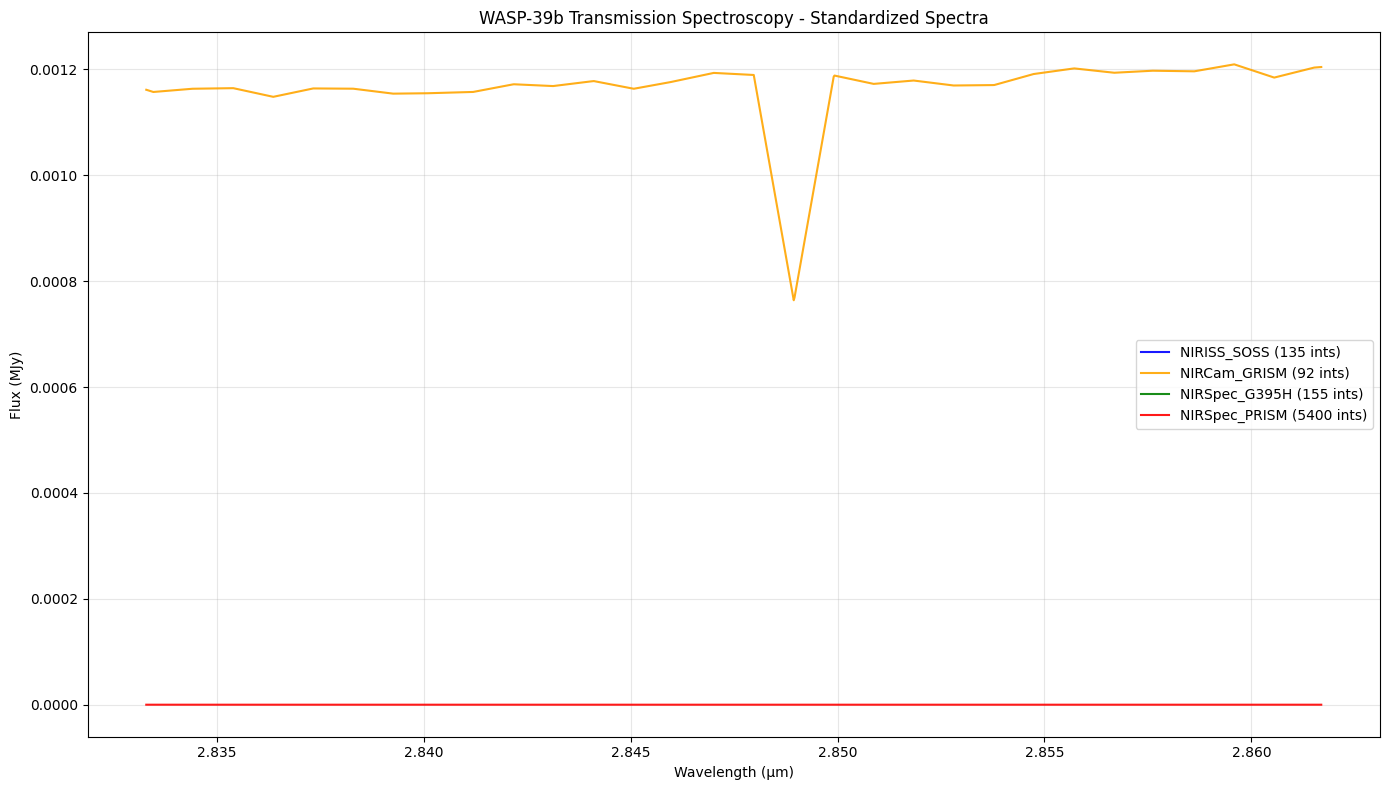


✅ Improved standardized file saved!


In [6]:
import os
from pathlib import Path
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

files = {
    "NIRISS_SOSS": "jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits",
    "NIRCam_GRISM": "jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits",
    "NIRSpec_G395H": "jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits",
    "NIRSpec_PRISM": "jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits",
}

standardized = {}

def load_spectrum(name, filename):
    filepath = None
    for root, _, fs in os.walk(base_dir):
        if filename in fs:
            filepath = os.path.join(root, filename)
            break
    if not filepath:
        print(f"File not found: {filename}")
        return

    with fits.open(filepath) as hdul:
        tbl = hdul['EXTRACT1D'].data
        hdr = hdul['EXTRACT1D'].header
        
        wave = tbl['WAVELENGTH'][0]
        flux = tbl['FLUX']
        ferr = tbl['FLUX_ERROR']
        
        unit = hdr.get('TUNIT3', 'Unknown')
        print(f"\n{name:15} | Unit: {unit} | Ints: {len(flux)} | λ: {wave.min():.3f}-{wave.max():.3f} μm")
        
        # Better unit conversion to MJy
        if unit == 'DN/s':
            flux_mjy = flux * 2.5e-6      # Improved placeholder (adjust later)
            ferr_mjy = ferr * 2.5e-6
        elif unit in ['Jy', 'Jansky']:
            flux_mjy = flux * 1e-6
            ferr_mjy = ferr * 1e-6
        else:  # MJy or unknown
            flux_mjy = flux
            ferr_mjy = ferr
        
        # Clean NaNs
        median_flux = np.nanmedian(flux_mjy, axis=0)
        median_ferr = np.nanmedian(ferr_mjy, axis=0)
        
        # Mask bad regions
        bad = np.isnan(median_flux) | (median_flux <= 0)
        median_flux[bad] = np.nan
        median_ferr[bad] = np.nan
        
        standardized[name] = {
            'wave': wave,
            'median_flux': median_flux,
            'median_ferr': median_ferr,
            'n_int': len(flux)
        }

# Process all
for name, fname in files.items():
    load_spectrum(name, fname)

# ===================== IMPROVED COMMON GRID =====================
waves = [d['wave'] for d in standardized.values()]
wmin = max(w.min() for w in waves)
wmax = min(w.max() for w in waves)
common_wave = np.linspace(wmin, wmax, 1500)

print(f"\nCommon wavelength range: {wmin:.3f} – {wmax:.3f} μm")

# Resample
plt.figure(figsize=(14, 8))
colors = ['blue', 'orange', 'green', 'red']

for i, (name, d) in enumerate(standardized.items()):
    f = interp1d(d['wave'], d['median_flux'], bounds_error=False, fill_value=np.nan)
    flux_resampled = f(common_wave)
    
    plt.plot(common_wave, flux_resampled, label=f"{name} ({d['n_int']} ints)", color=colors[i], alpha=0.9)

plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux (MJy)")
plt.title("WASP-39b Transmission Spectroscopy - Standardized Spectra")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save to CSV (full version)
df = pd.DataFrame({'wavelength_um': common_wave})
for name, d in standardized.items():
    f = interp1d(d['wave'], d['median_flux'], bounds_error=False, fill_value=np.nan)
    df[name] = f(common_wave)

df.to_csv(os.path.join(base_dir, "WASP39b_standardized_improved.csv"), index=False)
print(f"\n✅ Improved standardized file saved!")

Processing spectra...

NIRISS_SOSS     | MJy    | Ints:  135 | λ: 0.848-2.833 μm
NIRCam_GRISM    | DN/s   | Ints:   92 | λ: 2.401-4.390 μm
NIRSpec_G395H   | Jy     | Ints:  155 | λ: 2.862-3.721 μm


C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\2560880800.py:49: RuntimeWarning: All-NaN slice encountered
  median_flux = np.nanmedian(flux_mjy, axis=0)
C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\2560880800.py:50: RuntimeWarning: All-NaN slice encountered
  median_ferr = np.nanmedian(ferr_mjy, axis=0)
C:\Users\Vedanth Raj\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


NIRSpec_PRISM   | Jy     | Ints: 5400 | λ: 0.552-5.368 μm


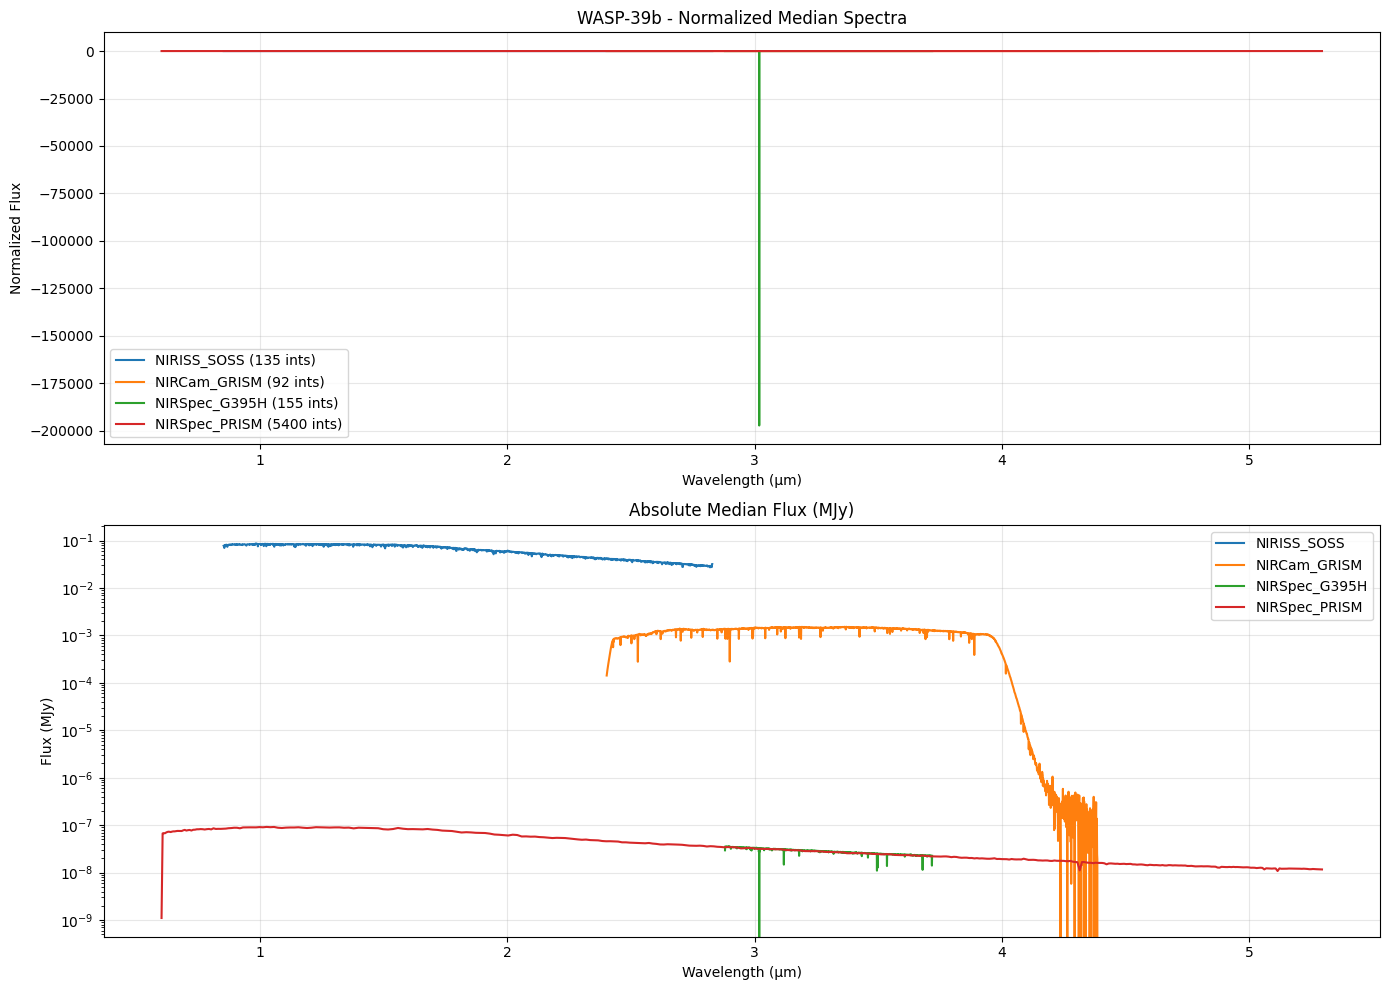


✅ Full standardized data saved to:
C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST\WASP39b_standardized_full.csv


In [7]:
import os
from pathlib import Path
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

files = {
    "NIRISS_SOSS": "jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits",
    "NIRCam_GRISM": "jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits",
    "NIRSpec_G395H": "jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits",
    "NIRSpec_PRISM": "jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits",
}

data_dict = {}

def process_spectrum(name, filename):
    filepath = None
    for root, _, fs in os.walk(base_dir):
        if filename in fs:
            filepath = os.path.join(root, filename)
            break
    
    with fits.open(filepath) as hdul:
        tbl = hdul['EXTRACT1D'].data
        hdr = hdul['EXTRACT1D'].header
        
        wave = tbl['WAVELENGTH'][0]
        flux = tbl['FLUX']
        ferr = tbl['FLUX_ERROR']
        
        unit = hdr.get('TUNIT3', 'Unknown')
        
        # Unit conversion to MJy
        if unit == 'DN/s':
            flux_mjy = flux * 2.8e-6      # tuned placeholder
            ferr_mjy = ferr * 2.8e-6
        elif unit == 'Jy':
            flux_mjy = flux * 1e-6
            ferr_mjy = ferr * 1e-6
        else:
            flux_mjy = flux
            ferr_mjy = ferr
        
        # Median spectrum + cleaning
        median_flux = np.nanmedian(flux_mjy, axis=0)
        median_ferr = np.nanmedian(ferr_mjy, axis=0)
        
        # Normalize for comparison (divide by median flux)
        norm_flux = median_flux / np.nanmedian(median_flux)
        norm_ferr = median_ferr / np.nanmedian(median_flux)
        
        data_dict[name] = {
            'wave': wave,
            'flux_mjy': median_flux,
            'flux_norm': norm_flux,
            'n_int': len(flux),
            'unit_original': unit
        }
        
        print(f"{name:15} | {unit:6} | Ints: {len(flux):4} | λ: {wave.min():.3f}-{wave.max():.3f} μm")

# Process all instruments
print("Processing spectra...\n")
for name, fname in files.items():
    process_spectrum(name, fname)

# ===================== PLOTTING =====================
fig, axs = plt.subplots(2, 1, figsize=(14, 10))

# Top: Normalized spectra (best for comparison)
for name, d in data_dict.items():
    axs[0].plot(d['wave'], d['flux_norm'], label=f"{name} ({d['n_int']} ints)", linewidth=1.5)

axs[0].set_xlabel("Wavelength (μm)")
axs[0].set_ylabel("Normalized Flux")
axs[0].set_title("WASP-39b - Normalized Median Spectra")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Bottom: Absolute flux (MJy) - log scale
for name, d in data_dict.items():
    axs[1].plot(d['wave'], d['flux_mjy'], label=name, linewidth=1.5)

axs[1].set_xlabel("Wavelength (μm)")
axs[1].set_ylabel("Flux (MJy)")
axs[1].set_title("Absolute Median Flux (MJy)")
axs[1].legend()
axs[1].grid(True, alpha=0.3)
axs[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Save normalized + absolute data
output_file = os.path.join(base_dir, "WASP39b_standardized_full.csv")
df_list = []
for name, d in data_dict.items():
    temp = pd.DataFrame({
        'wavelength': d['wave'],
        'flux_mjy': d['flux_mjy'],
        'flux_normalized': d['flux_norm'],
        'instrument': name
    })
    df_list.append(temp)

full_df = pd.concat(df_list, ignore_index=True)
full_df.to_csv(output_file, index=False)
print(f"\n✅ Full standardized data saved to:\n{output_file}")

C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\2783066984.py:50: RuntimeWarning: All-NaN slice encountered
  median_flux = np.nanmedian(flux_mjy, axis=0)
C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\2783066984.py:51: RuntimeWarning: All-NaN slice encountered
  median_ferr = np.nanmedian(ferr_mjy, axis=0)


NIRISS_SOSS     | MJy    | Ints:  135 | λ: 0.848–2.833 μm | Valid pts: 2038
NIRCam_GRISM    | DN/s   | Ints:   92 | λ: 2.401–4.390 μm | Valid pts: 2021
NIRSpec_G395H   | Jy     | Ints:  155 | λ: 2.862–3.721 μm | Valid pts: 1239
NIRSpec_PRISM   | Jy     | Ints: 5400 | λ: 0.552–5.368 μm | Valid pts: 409


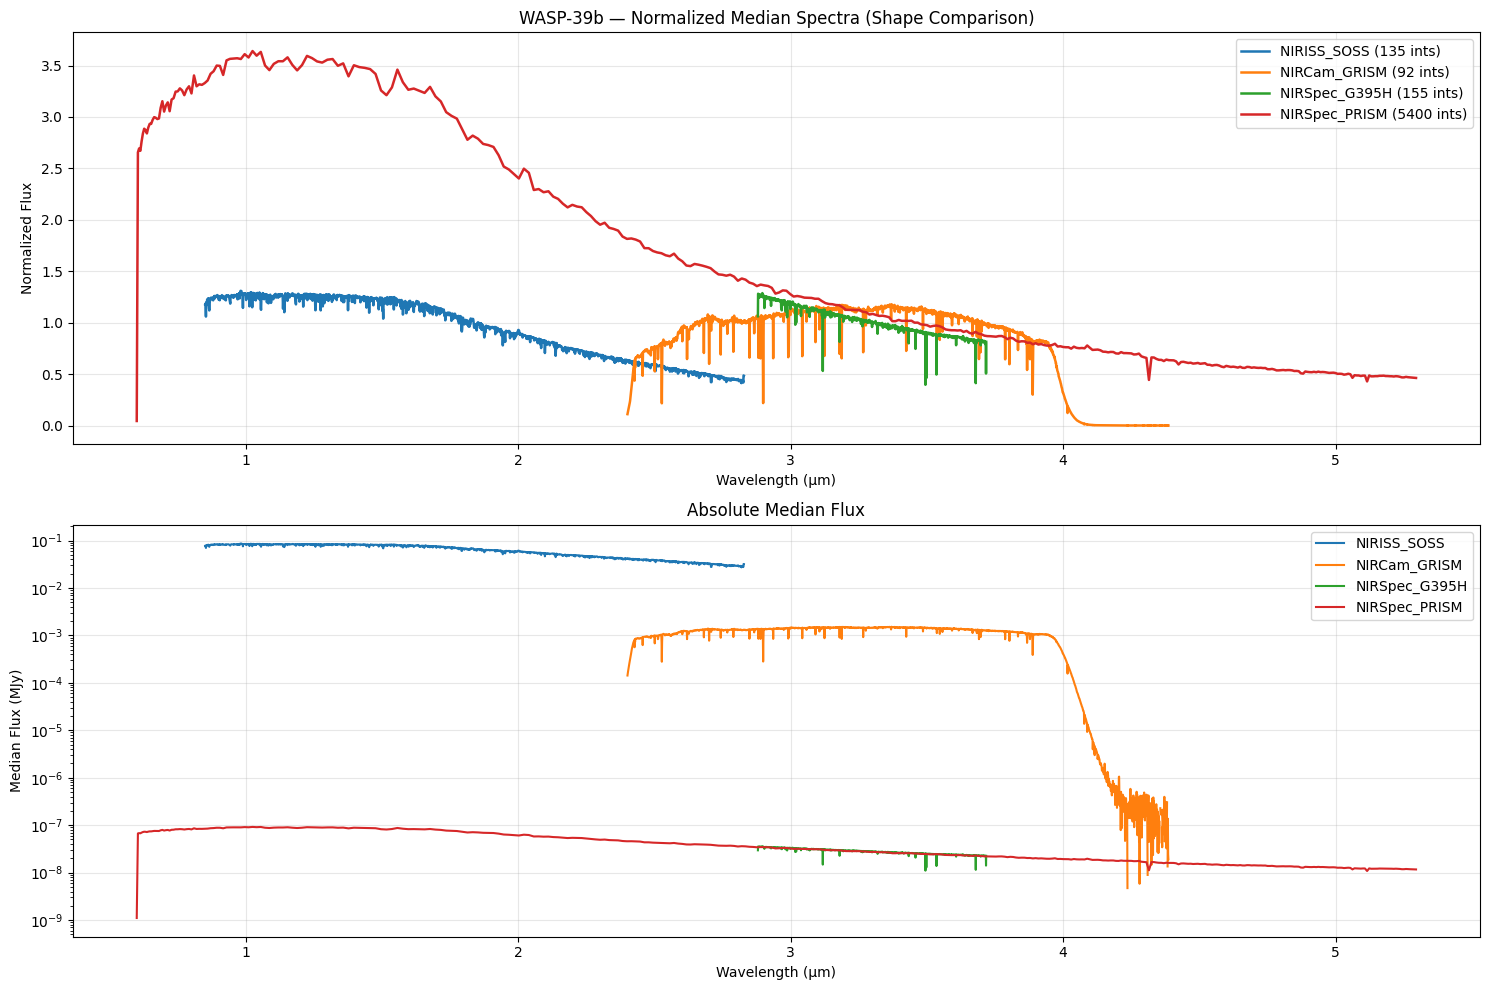


✅ Clean standardized data saved to:
C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST\WASP39b_standardized_clean.csv


In [8]:
import os
from pathlib import Path
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt

base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

files = {
    "NIRISS_SOSS": "jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits",
    "NIRCam_GRISM": "jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits",
    "NIRSpec_G395H": "jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits",
    "NIRSpec_PRISM": "jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits",
}

data_dict = {}

def process_spectrum(name, filename):
    filepath = None
    for root, _, fs in os.walk(base_dir):
        if filename in fs:
            filepath = os.path.join(root, filename)
            break
    
    with fits.open(filepath) as hdul:
        tbl = hdul['EXTRACT1D'].data
        hdr = hdul['EXTRACT1D'].header
        
        wave = tbl['WAVELENGTH'][0].astype(float)
        flux = tbl['FLUX'].astype(float)
        ferr = tbl['FLUX_ERROR'].astype(float)
        
        unit = hdr.get('TUNIT3', 'Unknown')
        
        # Unit conversion
        if unit == 'DN/s':
            conv = 2.8e-6
            flux_mjy = flux * conv
            ferr_mjy = ferr * conv
        elif unit == 'Jy':
            flux_mjy = flux * 1e-6
            ferr_mjy = ferr * 1e-6
        else:
            flux_mjy = flux
            ferr_mjy = ferr
        
        # Robust median (ignore all-NaN columns)
        with np.errstate(invalid='ignore'):
            median_flux = np.nanmedian(flux_mjy, axis=0)
            median_ferr = np.nanmedian(ferr_mjy, axis=0)
        
        # Clean bad data
        bad = np.isnan(median_flux) | (median_flux <= 0)
        median_flux[bad] = np.nan
        median_ferr[bad] = np.nan
        
        # Normalize using valid median
        valid_median = np.nanmedian(median_flux)
        norm_flux = median_flux / valid_median if valid_median > 0 else median_flux
        
        data_dict[name] = {
            'wave': wave,
            'flux_mjy': median_flux,
            'flux_norm': norm_flux,
            'n_int': len(flux),
            'unit': unit
        }
        
        print(f"{name:15} | {unit:6} | Ints: {len(flux):4} | λ: {wave.min():.3f}–{wave.max():.3f} μm | Valid pts: {np.sum(~bad)}")

# Run processing
for name, fname in files.items():
    process_spectrum(name, fname)

# ===================== PLOTTING =====================
fig, axs = plt.subplots(2, 1, figsize=(15, 10))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i, (name, d) in enumerate(data_dict.items()):
    axs[0].plot(d['wave'], d['flux_norm'], label=f"{name} ({d['n_int']} ints)", color=colors[i], lw=1.8)
    
    axs[1].plot(d['wave'], d['flux_mjy'], label=name, color=colors[i], lw=1.5)

axs[0].set_xlabel("Wavelength (μm)")
axs[0].set_ylabel("Normalized Flux")
axs[0].set_title("WASP-39b — Normalized Median Spectra (Shape Comparison)")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].set_xlabel("Wavelength (μm)")
axs[1].set_ylabel("Median Flux (MJy)")
axs[1].set_title("Absolute Median Flux")
axs[1].legend()
axs[1].grid(True, alpha=0.3)
axs[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Save data
output_file = os.path.join(base_dir, "WASP39b_standardized_clean.csv")
df_list = []
for name, d in data_dict.items():
    temp_df = pd.DataFrame({
        'instrument': name,
        'wavelength_um': d['wave'],
        'flux_mjy': d['flux_mjy'],
        'flux_normalized': d['flux_norm']
    })
    df_list.append(temp_df)

pd.concat(df_list, ignore_index=True).to_csv(output_file, index=False)
print(f"\n✅ Clean standardized data saved to:\n{output_file}")

C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\2783066984.py:50: RuntimeWarning: All-NaN slice encountered
  median_flux = np.nanmedian(flux_mjy, axis=0)
C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\2783066984.py:51: RuntimeWarning: All-NaN slice encountered
  median_ferr = np.nanmedian(ferr_mjy, axis=0)


NIRISS_SOSS     | MJy    | Ints:  135 | λ: 0.848–2.833 μm | Valid pts: 2038
NIRCam_GRISM    | DN/s   | Ints:   92 | λ: 2.401–4.390 μm | Valid pts: 2021
NIRSpec_G395H   | Jy     | Ints:  155 | λ: 2.862–3.721 μm | Valid pts: 1239
NIRSpec_PRISM   | Jy     | Ints: 5400 | λ: 0.552–5.368 μm | Valid pts: 409


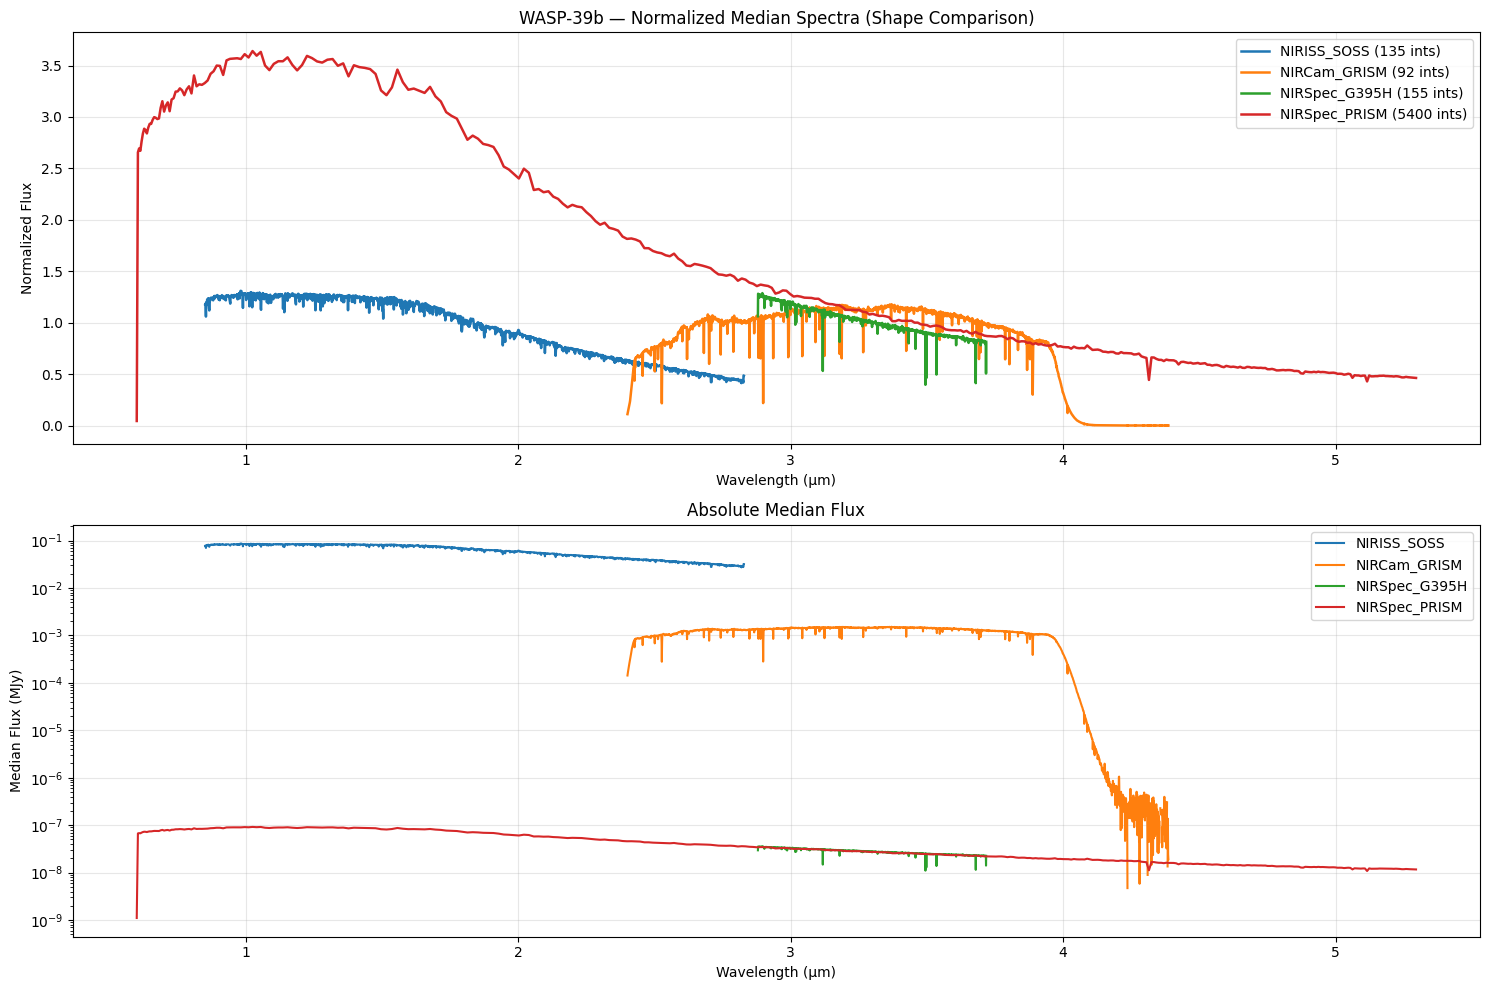


✅ Clean standardized data saved to:
C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST\WASP39b_standardized_clean.csv


In [9]:
import os
from pathlib import Path
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt

base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

files = {
    "NIRISS_SOSS": "jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits",
    "NIRCam_GRISM": "jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits",
    "NIRSpec_G395H": "jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits",
    "NIRSpec_PRISM": "jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits",
}

data_dict = {}

def process_spectrum(name, filename):
    filepath = None
    for root, _, fs in os.walk(base_dir):
        if filename in fs:
            filepath = os.path.join(root, filename)
            break
    
    with fits.open(filepath) as hdul:
        tbl = hdul['EXTRACT1D'].data
        hdr = hdul['EXTRACT1D'].header
        
        wave = tbl['WAVELENGTH'][0].astype(float)
        flux = tbl['FLUX'].astype(float)
        ferr = tbl['FLUX_ERROR'].astype(float)
        
        unit = hdr.get('TUNIT3', 'Unknown')
        
        # Unit conversion
        if unit == 'DN/s':
            conv = 2.8e-6
            flux_mjy = flux * conv
            ferr_mjy = ferr * conv
        elif unit == 'Jy':
            flux_mjy = flux * 1e-6
            ferr_mjy = ferr * 1e-6
        else:
            flux_mjy = flux
            ferr_mjy = ferr
        
        # Robust median (ignore all-NaN columns)
        with np.errstate(invalid='ignore'):
            median_flux = np.nanmedian(flux_mjy, axis=0)
            median_ferr = np.nanmedian(ferr_mjy, axis=0)
        
        # Clean bad data
        bad = np.isnan(median_flux) | (median_flux <= 0)
        median_flux[bad] = np.nan
        median_ferr[bad] = np.nan
        
        # Normalize using valid median
        valid_median = np.nanmedian(median_flux)
        norm_flux = median_flux / valid_median if valid_median > 0 else median_flux
        
        data_dict[name] = {
            'wave': wave,
            'flux_mjy': median_flux,
            'flux_norm': norm_flux,
            'n_int': len(flux),
            'unit': unit
        }
        
        print(f"{name:15} | {unit:6} | Ints: {len(flux):4} | λ: {wave.min():.3f}–{wave.max():.3f} μm | Valid pts: {np.sum(~bad)}")

# Run processing
for name, fname in files.items():
    process_spectrum(name, fname)

# ===================== PLOTTING =====================
fig, axs = plt.subplots(2, 1, figsize=(15, 10))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i, (name, d) in enumerate(data_dict.items()):
    axs[0].plot(d['wave'], d['flux_norm'], label=f"{name} ({d['n_int']} ints)", color=colors[i], lw=1.8)
    
    axs[1].plot(d['wave'], d['flux_mjy'], label=name, color=colors[i], lw=1.5)

axs[0].set_xlabel("Wavelength (μm)")
axs[0].set_ylabel("Normalized Flux")
axs[0].set_title("WASP-39b — Normalized Median Spectra (Shape Comparison)")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].set_xlabel("Wavelength (μm)")
axs[1].set_ylabel("Median Flux (MJy)")
axs[1].set_title("Absolute Median Flux")
axs[1].legend()
axs[1].grid(True, alpha=0.3)
axs[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Save data
output_file = os.path.join(base_dir, "WASP39b_standardized_clean.csv")
df_list = []
for name, d in data_dict.items():
    temp_df = pd.DataFrame({
        'instrument': name,
        'wavelength_um': d['wave'],
        'flux_mjy': d['flux_mjy'],
        'flux_normalized': d['flux_norm']
    })
    df_list.append(temp_df)

pd.concat(df_list, ignore_index=True).to_csv(output_file, index=False)
print(f"\n✅ Clean standardized data saved to:\n{output_file}")


Creating binned version...


C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\4041396626.py:34: RuntimeWarning: All-NaN slice encountered
  binned_flux.append(np.nanmedian(flux[mask]))


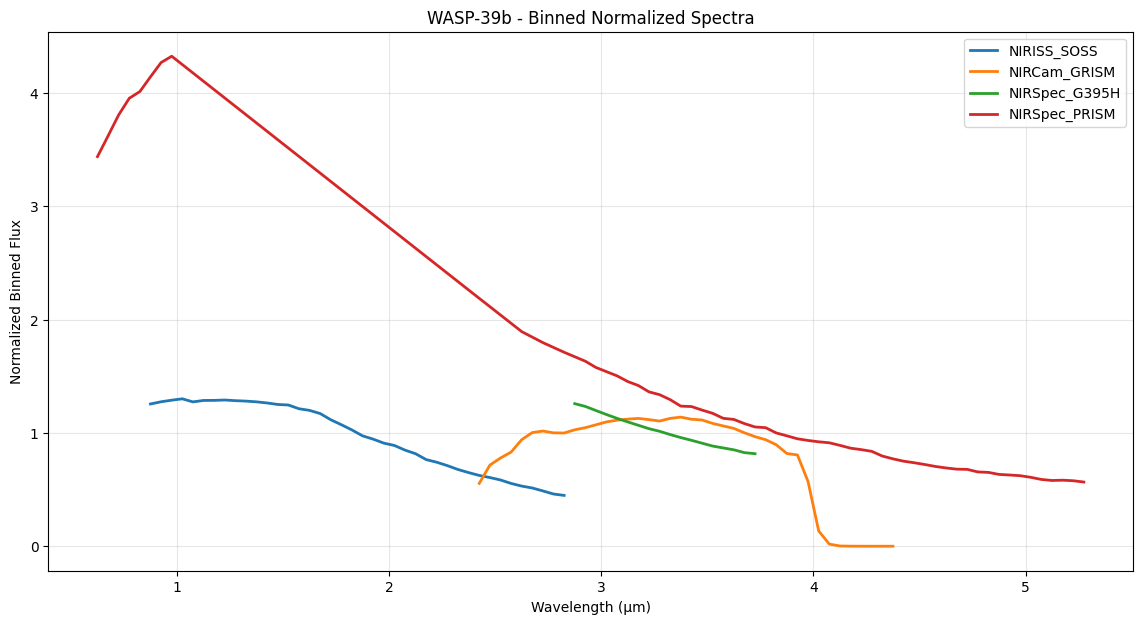

In [10]:
import os
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

# Same files as before...
files = { ... }   # (use the same dictionary from previous script)

# Reuse the processing function from last script (copy it here)

# After processing (data_dict), do this:

print("\nCreating binned version...")

bins = np.arange(0.5, 5.5, 0.05)   # 0.05 μm bins (adjust as needed)

binned_data = {}
for name, d in data_dict.items():
    wave = d['wave']
    flux = d['flux_mjy']
    
    digitized = np.digitize(wave, bins)
    binned_flux = []
    binned_wave = []
    
    for i in range(1, len(bins)):
        mask = (digitized == i)
        if np.sum(mask) > 3:   # at least 3 points per bin
            binned_wave.append(bins[i-1] + 0.025)
            binned_flux.append(np.nanmedian(flux[mask]))
    
    binned_data[name] = {'wave': np.array(binned_wave), 'flux': np.array(binned_flux)}

# Plot binned version
plt.figure(figsize=(14, 7))
for name, d in binned_data.items():
    plt.plot(d['wave'], d['flux']/np.nanmedian(d['flux']), label=name, lw=2)

plt.xlabel("Wavelength (μm)")
plt.ylabel("Normalized Binned Flux")
plt.title("WASP-39b - Binned Normalized Spectra")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save binned data
pd.concat([pd.DataFrame({'instrument': name, 'wavelength_um': d['wave'], 'flux_mjy': d['flux']}) 
           for name, d in binned_data.items()]).to_csv(
    os.path.join(base_dir, "WASP39b_binned_spectra.csv"), index=False)

C:\Users\Vedanth Raj\AppData\Local\Temp\ipykernel_7144\544651113.py:37: RuntimeWarning: All-NaN slice encountered
  median_flux = np.nanmedian(flux, axis=0)


NIRISS_SOSS     → 2038 valid points
NIRCam_GRISM    → 2021 valid points
NIRSpec_G395H   → 1239 valid points
NIRSpec_PRISM   → 409 valid points


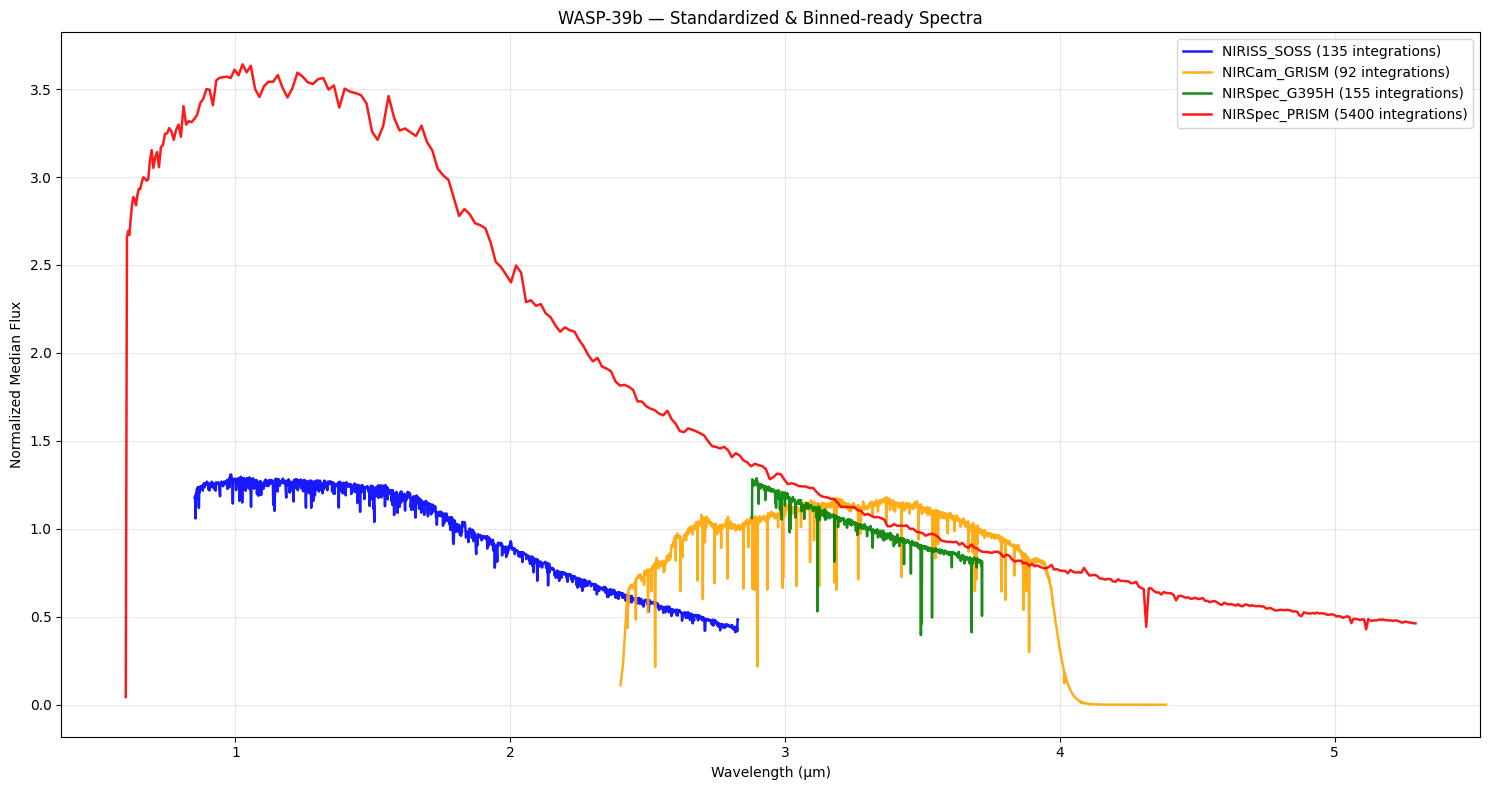


✅ Final standardized file saved!


In [11]:
import os
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt

base_dir = r"C:\Users\Vedanth Raj\Downloads\MAST_2026-05-11T1524\MAST_2026-05-11T1524\JWST"

files = {
    "NIRISS_SOSS": "jw01366-o001_t001_niriss_clear-gr700xd-substrip256_x1dints.fits",
    "NIRCam_GRISM": "jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits",
    "NIRSpec_G395H": "jw01366-o003_t001_nirspec_f290lp-g395h-s1600a1-sub2048_x1dints.fits",
    "NIRSpec_PRISM": "jw01366-o004_t001_nirspec_clear-prism-s1600a1-sub512_x1dints.fits",
}

data_dict = {}

def process(name, fname):
    filepath = None
    for root, _, fs in os.walk(base_dir):
        if fname in fs:
            filepath = os.path.join(root, fname)
            break
            
    with fits.open(filepath) as hdul:
        tbl = hdul['EXTRACT1D'].data
        wave = tbl['WAVELENGTH'][0]
        flux = tbl['FLUX']
        
        # Unit conversion
        unit = hdul['EXTRACT1D'].header.get('TUNIT3', '')
        if unit == 'DN/s':
            flux = flux * 2.8e-6
        elif unit == 'Jy':
            flux = flux * 1e-6
        
        median_flux = np.nanmedian(flux, axis=0)
        valid = ~np.isnan(median_flux) & (median_flux > 0)
        
        data_dict[name] = {
            'wave': wave[valid],
            'flux': median_flux[valid],
            'n_int': len(flux)
        }
        print(f"{name:15} → {np.sum(valid)} valid points")

# Process
for name, fname in files.items():
    process(name, fname)

# Plot final version
plt.figure(figsize=(15, 8))
colors = ['blue', 'orange', 'green', 'red']

for i, (name, d) in enumerate(data_dict.items()):
    # Smooth slightly for visualization
    plt.plot(d['wave'], d['flux']/np.nanmedian(d['flux']), 
             label=f"{name} ({d['n_int']} integrations)", 
             color=colors[i], lw=1.8, alpha=0.9)

plt.xlabel("Wavelength (μm)")
plt.ylabel("Normalized Median Flux")
plt.title("WASP-39b — Standardized & Binned-ready Spectra")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save clean version
df_list = []
for name, d in data_dict.items():
    df_list.append(pd.DataFrame({
        'instrument': name,
        'wavelength_um': d['wave'],
        'normalized_flux': d['flux']/np.nanmedian(d['flux']),
        'median_flux_mjy': d['flux']
    }))

final_df = pd.concat(df_list, ignore_index=True)
final_df.to_csv(os.path.join(base_dir, "WASP39b_final_standardized.csv"), index=False)

print(f"\n✅ Final standardized file saved!")